## Objetivo

El objetivo de este notebook será demostrar la efectividad de el uso de ventanas móviles con *Weighted Moving Average* como un pretratamiento de la data para predecir el precio de cierre de los siguientes 5 días para la acción *KO*. 
Dada la no linealidad de la serie de tiempo, usaremos *WMA* que ayudará a suavizar el la curva del precio de cierre asignando un factor de peso a cada valor en el tiempo basado en su aparición en la serie.

El preprocesamiento alimentará a una red *LSTM*. Dado que *LSTM* usa el pasado secuencial para predecir los valores futuros, neesita que los vectores que introduzcamos tengan una dimensión de $(n_samples, timesteps, n_features)$

$$y_t = f(x_t, x_{t-1}, \ldots, x_{t-k})$$

## Dependencias


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler


from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
import plotly.express as px
import plotly.graph_objects as go

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from keras import metrics
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


from functools import reduce
from dateutil.relativedelta import relativedelta as rd

import warnings
import os 

warnings.filterwarnings('ignore')
cf.go_offline()
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:,.4f}'.format)

## Lectura de Datos

Para obtener los datos de *KO* utilizaremos la API de Yahoo Finance.

In [47]:
df_KO = yf.download(
    'KO',
    start='2020-01-01',
    end='2026-03-10'
)

df_KO.columns = [c[0] for c in df_KO.columns]

df_KO.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,45.4327,45.7962,45.2427,45.7053,11867700
2020-01-03,45.1849,45.4327,44.6891,44.8792,11354500
2020-01-06,45.1683,45.3666,45.0444,45.1518,14698300
2020-01-07,44.8213,45.1105,44.7387,44.9866,9973900
2020-01-08,44.9039,45.1435,44.7387,44.8378,10676000


In [48]:
df = df_KO.copy()

In [49]:
fig = px.line(
    df,
    x=df.index,
    y='Close',
    title='Precio de Cierre de KO'
)

fig.update_layout(
    xaxis_title = 'Fecha',
    yaxis_title = 'Precio de Cierre',
    template="plotly_white"
)

fig.show()

## EDA

In [50]:
# Revisamos vacíos
df.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [51]:
# Revisamos los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1553 entries, 2020-01-02 to 2026-03-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1553 non-null   float64
 1   High    1553 non-null   float64
 2   Low     1553 non-null   float64
 3   Open    1553 non-null   float64
 4   Volume  1553 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 72.8 KB


In [52]:
df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Close,High,Low,Open,Volume
count,"1,553.0000","1,553.0000","1,553.0000","1,553.0000","1,553.0000"
mean,55.0989,55.5014,54.6743,55.0996,"15,659,981.4552"
std,9.5163,9.5194,9.4640,9.4806,"6,647,101.0838"
min,31.3042,32.4127,30.2291,32.3043,"3,265,500.0000"
1%,37.0292,37.7181,36.4385,37.1141,"7,164,548.0000"
25%,47.7791,48.0600,47.5011,47.7897,"11,679,400.0000"
50%,55.2784,55.6897,54.9031,55.3048,"14,248,400.0000"
75%,60.4294,60.9164,60.1207,60.4628,"17,668,200.0000"
99%,77.7621,78.5388,77.0343,77.5889,"42,483,828.0000"
max,81.0030,81.4400,80.2681,80.6951,"67,845,700.0000"


Los percentiles $1\%$ y $99\%$ nos indican presencia de outliers. Estos los podremos visualizar en los histogramas de las distribuciones.

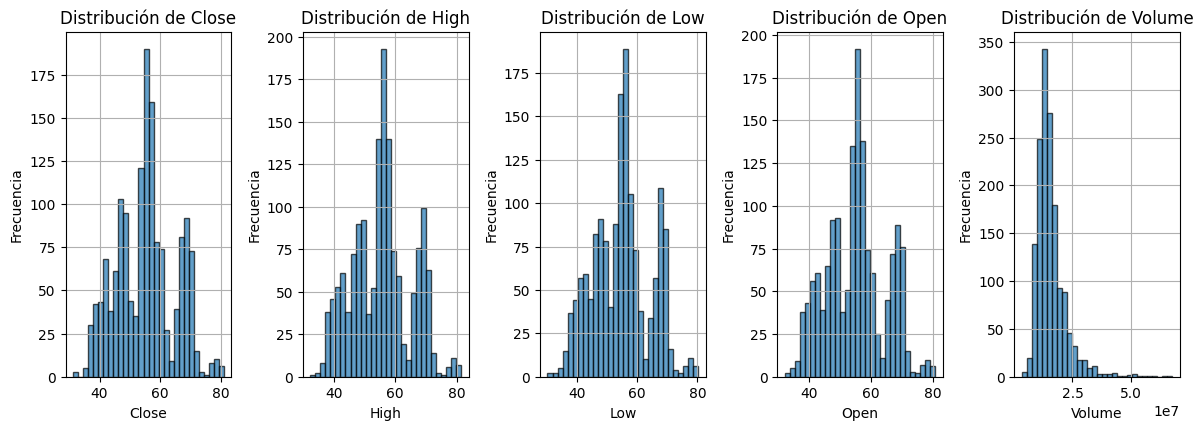

In [53]:
# Revisamos las distribuciones

num_cols = len(df.columns)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols,
    figsize=(12, num_rows*4)
)
axes = axes.flatten()

for i, column in enumerate(list(df.columns)):
    df[column].hist(ax=axes[i],bins=30,edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribución de {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frecuencia')
    
for j in range( i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

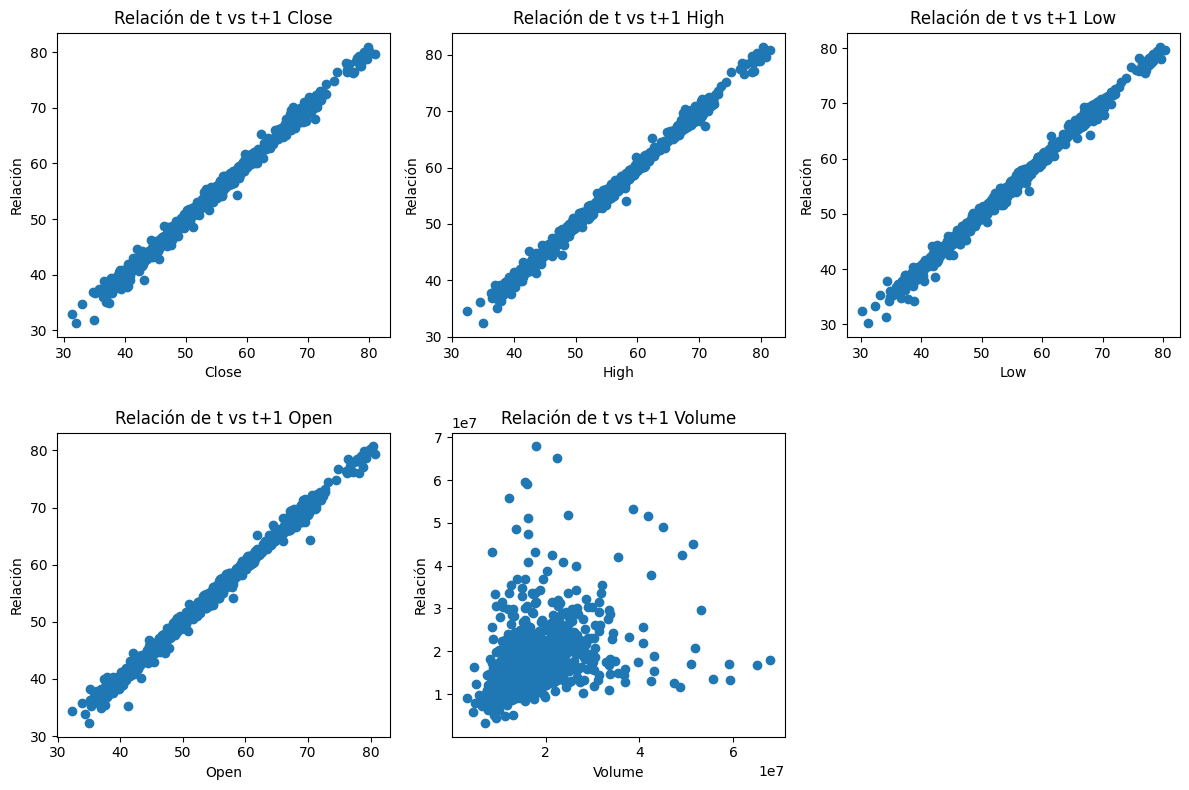

In [54]:
num_cols = len(df.columns)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=3,
    figsize=(12, num_rows*4)
)
axes = axes.flatten()

for i, column in enumerate(list(df.columns)):
    pd.plotting.lag_plot(df[column], ax=axes[i])
    axes[i].set_title(f'Relación de t vs t+1 {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Relación')
    
for j in range( i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


# pd.plotting.lag_plot(df['Close'])
# plt.show()

Notamos que la relación de hoy y el día siguiente es líneal a excepción del volumen,

## Definición del Proyecto

In [10]:
# Redefinimos el index

df.reset_index(inplace=True)
display(df.head(3))

# Cambiamos el formato de Date para poder operar con fechas

df['Date'] = df['Date'].dt.date

,Date,Close,High,Low,Open,Volume
0,2020-01-02,45.4327,45.7962,45.2427,45.7053,11867700
1,2020-01-03,45.1849,45.4327,44.6891,44.8792,11354500
2,2020-01-06,45.1683,45.3666,45.0444,45.1518,14698300


In [11]:
# Para modelar, sólo usaré dos años de datos

fhi, fhf = df['Date'].max() + rd(years=-5), df['Date'].max()

print(f"La fecha inicial es {fhi} y la fecha final es {fhf}")

La fecha inicial es 2021-03-09 y la fecha final es 2026-03-09


In [12]:
# Limitamos la data

df = df.loc[df['Date']>=fhi].reset_index(drop = True).copy()

In [13]:
df = df.set_index('Date')

## Feature Engineering

Como *feature engineering*, se aplicará *sliding window* con Weighted Moving Average para 5, 10, 15 y 20 días.

El WMA se define de la siguiente manera:
$$F_t = \frac{\sum^{n}_{i=1} W_i\cdot A_{t-1}}{\sum^{n}_{i=1} W_i}$$

In [14]:
# Creamos la función que nos ayudará a crear las ventanas con WMA

def WMA(series, window):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(
        lambda x: np.dot(weights, x) / weights.sum(),
        raw=True
    )

In [15]:
windows = [5, 10, 15, 20]
cols = list(df.columns)

for col in cols:
    for w in windows:
        
        df[f'{col}_wma_{w}'] = WMA(df[col], w)
        

df.head(10)

,Close,High,Low,Open,Volume,Close_wma_5,Close_wma_10,Close_wma_15,Close_wma_20,High_wma_5,High_wma_10,High_wma_15,High_wma_20,Low_wma_5,Low_wma_10,Low_wma_15,Low_wma_20,Open_wma_5,Open_wma_10,Open_wma_15,Open_wma_20,Volume_wma_5,Volume_wma_10,Volume_wma_15,Volume_wma_20
Date,,,,,,,,,,,,,,,,,,,,,,,,,
2021-03-09,43.4585,44.3300,43.4243,44.1933,23082700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-10,43.9541,44.1164,43.3389,43.7319,21331600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-11,43.4756,43.9455,43.4158,43.9284,17417700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-12,43.3894,43.6651,43.2516,43.5876,17598600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-15,43.9667,44.0442,43.4842,43.5100,13411900,43.6790,NaN,NaN,NaN,43.9521,NaN,NaN,NaN,43.3851,NaN,NaN,NaN,43.6895,NaN,NaN,NaN,"17,030,193.3333",NaN,NaN,NaN
2021-03-16,44.1304,44.3888,43.9753,44.1131,14214200,43.8395,NaN,NaN,NaN,44.0749,NaN,NaN,NaN,43.5825,NaN,NaN,NaN,43.7972,NaN,NaN,NaN,"15,578,760.0000",NaN,NaN,NaN
2021-03-17,44.1476,44.4750,44.0701,44.1562,17502700,43.9609,NaN,NaN,NaN,44.2226,NaN,NaN,NaN,43.7749,NaN,NaN,NaN,43.9245,NaN,NaN,NaN,"15,814,726.6667",NaN,NaN,NaN
2021-03-18,43.5703,44.1045,43.5014,43.9925,18007300,43.8771,NaN,NaN,NaN,44.2228,NaN,NaN,NaN,43.7289,NaN,NaN,NaN,43.9690,NaN,NaN,NaN,"16,474,153.3333",NaN,NaN,NaN
2021-03-19,43.7771,44.0098,43.2257,43.4756,67845700,43.8558,NaN,NaN,NaN,44.1809,NaN,NaN,NaN,43.5853,NaN,NaN,NaN,43.8369,NaN,NaN,NaN,"33,707,073.3333",NaN,NaN,NaN


In [16]:
# Eliminamos los vacíos resultantes del rolling

df.dropna(inplace=True)

df.head()

,Close,High,Low,Open,Volume,Close_wma_5,Close_wma_10,Close_wma_15,Close_wma_20,High_wma_5,High_wma_10,High_wma_15,High_wma_20,Low_wma_5,Low_wma_10,Low_wma_15,Low_wma_20,Open_wma_5,Open_wma_10,Open_wma_15,Open_wma_20,Volume_wma_5,Volume_wma_10,Volume_wma_15,Volume_wma_20
Date,,,,,,,,,,,,,,,,,,,,,,,,,
2021-04-06,45.8277,46.2240,45.5778,45.6985,15614300,45.5658,45.5393,45.2450,44.9962,45.9920,45.8889,45.5603,45.3003,45.3176,45.1408,44.8181,44.5844,45.5658,45.4224,45.0839,44.8458,"15,838,346.6667","16,080,721.8182","17,996,125.0000","18,587,182.8571"
2021-04-07,45.9052,46.0948,45.7674,45.9052,10062700,45.6824,45.6428,45.3754,45.1245,46.0218,45.9731,45.6779,45.4169,45.4624,45.3053,44.9828,44.7353,45.6387,45.5625,45.2350,44.9825,"13,958,180.0000","14,961,525.4545","16,773,428.3333","17,685,980.0000"
2021-04-08,45.7674,45.9914,45.6381,45.8105,9695600,45.7456,45.6917,45.4739,45.2279,46.0339,46.0094,45.7684,45.5152,45.5531,45.4104,45.1163,44.8626,45.7071,45.6494,45.3594,45.1021,"12,276,253.3333","13,900,565.4545","15,539,440.0000","16,811,815.2381"
2021-04-09,45.8191,45.9052,45.5003,45.8105,10828200,45.8024,45.7249,45.5653,45.3277,46.0052,46.0067,45.8354,45.5965,45.5709,45.4619,45.2196,44.9659,45.7674,45.7050,45.4699,45.2117,"11,380,586.6667","13,141,929.0909","14,512,085.8333","16,100,926.6667"
2021-04-12,45.9655,46.1379,45.7501,45.9483,8565300,45.8696,45.7666,45.6562,45.4303,46.0465,46.0273,45.9166,45.6905,45.6519,45.5332,45.3374,45.0831,45.8616,45.7627,45.5826,45.3255,"10,064,386.6667","12,085,741.8182","13,261,695.0000","15,205,902.3810"


In [17]:
# Creamos la target

df['target'] = df['Close'].shift(-1)

df[['Close','target']].tail(10)

,Close,target
Date,,
2026-02-24,80.1688,79.9205
2026-02-25,79.9205,79.9503
2026-02-26,79.9503,81.0030
2026-02-27,81.0030,79.6722
2026-03-02,79.6722,78.7982
2026-03-03,78.7982,77.5667
2026-03-04,77.5667,76.5040
2026-03-05,76.5040,76.5139
2026-03-06,76.5139,77.2687


In [18]:
df.isna().sum()

Close            0
High             0
Low              0
Open             0
Volume           0
Close_wma_5      0
Close_wma_10     0
Close_wma_15     0
Close_wma_20     0
High_wma_5       0
High_wma_10      0
High_wma_15      0
High_wma_20      0
Low_wma_5        0
Low_wma_10       0
Low_wma_15       0
Low_wma_20       0
Open_wma_5       0
Open_wma_10      0
Open_wma_15      0
Open_wma_20      0
Volume_wma_5     0
Volume_wma_10    0
Volume_wma_15    0
Volume_wma_20    0
target           1
dtype: int64

In [19]:
df.dropna(inplace=True)

In [20]:
# Definimos las variables
varc = [col for col in df.columns if 'wma' in col]

X = df[varc]

y = df['target']

## Partición

Usaremos el método `split` de `TimeSeriesSplit`

In [21]:
tscv = TimeSeriesSplit(n_splits=10, test_size=120)

for train_idx, test_idx in tscv.split(X):
    X_train_raw = X.iloc[train_idx]
    X_test_raw = X.iloc[test_idx]
    
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

Como observamos en el `EDA`, la data cuenta con outliers (muy común en data financiera) y dado que no queremos deshacernos de nuestra data pues representan valores reales, usaremos `RobustScaler`. Este método es perfecto ya que escala restando la mediana y divide por el rango intercuanrílico.


$$ X_{escalado} = \frac{X-Mediana}{IQR} $$

In [ ]:
rs = RobustScaler()

X_train_scaled = rs.fit_transform(X_train_raw)
X_test_scaled = rs.transform(X_test_raw)

In [23]:
# Definimos la función de secuencias para poder alimentar a nuestro modelo LSTM

def vectores_LSTM(X, y, window=30, horizon=5):
    Xs, ys = [], []
    
    for i in range(len(X) - window - horizon +1):
        Xs.append(X[i:i + window])
        ys.append(y[i + window:i + window + horizon])
        
    return np.array(Xs), np.array(ys)

In [24]:
X_train, y_train = vectores_LSTM(X_train_scaled, y_train)

X_test, y_test = vectores_LSTM(X_test_scaled, y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1082, 30, 20), (1082, 5), (86, 30, 20), (86, 5))

## Aprendizaje

In [25]:
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(30, X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(5)
])

In [26]:
# Configuración del modelo

kmetrics = [
    metrics.RootMeanSquaredError(name='rms'),
    metrics.MeanAbsoluteError(name='mae')
]

In [27]:
# Callbacks

early_stopping = EarlyStopping(monitor='val_mae', patience=20)

In [28]:
model.compile(optimizer='adam',loss='mse', metrics=kmetrics)

## Entrenamiento

In [29]:
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=1,
    callbacks=[early_stopping],
    validation_data=(X_test, y_test)
)

Epoch 1/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 492.6542 - mae: 12.1181 - rms: 22.1958 - val_loss: 25.7348 - val_mae: 3.6462 - val_rms: 5.0729
Epoch 2/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.1821 - mae: 1.1390 - rms: 1.4772 - val_loss: 19.9201 - val_mae: 3.0616 - val_rms: 4.4632
Epoch 3/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.1176 - mae: 1.1225 - rms: 1.4552 - val_loss: 20.8635 - val_mae: 3.2430 - val_rms: 4.5677
Epoch 4/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.0291 - mae: 1.0912 - rms: 1.4245 - val_loss: 16.6734 - val_mae: 2.8589 - val_rms: 4.0833
Epoch 5/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.1572 - mae: 1.1278 - rms: 1.4687 - val_loss: 22.2794 - val_mae: 3.4306 - val_rms: 4.7201
Epoch 6/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 33.5974 - mae: 2.8443 - rms: 5.7963 - val_loss: 38.0211 - val_mae: 4.4518 - val_rms: 6.1661
Epoch 7/50
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 4.2863 - mae: 1

In [30]:
preds = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [ ]:
# MAE
mae_por_dia = []

for i in range(5):
    mae = mean_absolute_error(y_test[:,i], preds[:,i])
    mae_por_dia.append(mae)
    
print(f"MAE por día: {mae_por_dia}")

MAE por día: [3.48334591887718, 3.8381523309751997, 3.803694170574809, 3.8509387526401255, 4.071158741795739]


In [ ]:
# MAPE
mape_por_dia = []

for i in range(5):
    mape = mean_absolute_percentage_error(y_test[:,i], preds[:,i])
    mape_por_dia.append(mape)
    
print(f"MAPE por día: {list(map(lambda x: x*100,mape_por_dia))}")

MAPE por día: [4.631822180344676, 5.106933935372034, 5.059576962528416, 5.117644050478451, 5.408519870914083]


In [34]:
mape_glob = mean_absolute_percentage_error(y_test.flatten(), preds.flatten())

print(f"El MAPE global es de {mape_glob*100}")

El MAPE global es de 5.064899399927532


In [36]:
y_test_1 = y_test[0]
y_pred_1 = preds[0]

In [37]:
index_test = df.index[-len(y_test_1):]


In [38]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=index_test,
    y=y_test_1,
    mode='lines',
    name='Real'
))

fig.add_trace(go.Scatter(
    x=index_test,
    y=y_pred_1,
    mode='lines',
    name='Predicción'
))

fig.update_layout(
    title='Predicción vs Real (t+1)',
    xaxis_title='Fecha',
    yaxis_title='Precio',
    template='plotly_dark'
)

fig.show()